# Tutorial H<sup>2</sup>MM analysis for $\mathrm{\mu sALEX}$ systems

To start with H<sup>2</sup>MM analysis, an appropriate burst selection is necessary.

The cell below sets up a starting point to enter into H<sup>2</sup>MM analysis.

In [1]:
import os
from itertools import chain, product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import smfbursts as smf
import H2MMbursts as bhm
import H2MM_C as hm

raw = smf.loadraw.load_dir('data/Apo_50us ALEX_1hr/', finalizer='raw')
data = smf.photonHDF5.regularize_dets(raw)
dbs = smf.fretfactory.make_bg(data, period=60.0, func=smf.bg.exp_mlefit,
                              tail_min=5e-4, auto_threshold=True,  
                              F_bg=1.7)

smf.fretfactory.make_burst_search(bg=dbs['bg'], m=10, F=6.0, 
                                  streams=smf.PhSel('0ex_1ex1em'),
                                  update=dbs, nbva=5)

gate_All = smf.make_geq_gate(dbs['NphDex_raw'], 50) & smf.make_geq_gate(dbs['NphAA_raw'], 30)
gate_FRET = gate_All & smf.make_range_gate(dbs['S_bg'], 0.25, 0.7)
smf.fretfactory.apply_gate(dbs, gate_FRET);

## Standard $\mathrm{H^{2}MM}$ analysis

H<sup>2</sup>MM analysis is designed for the characterization of within burst dynamics.
This is usually seen as a sign of conformational dynamics for FRET labeled biomolecules.

A brief outline of the pipeline of the H<sup>2</sup>MM analysis pipelife proceeds as follows:
1. Before $\mathrm{H^{2}MM}$
    1. Burst search
        - Identify single molecule bursts
        - trim and select (gating) burst population to those of interest (and significance, ie sufficient size)
    2. Qualitative Checks
        - Histograms and scatterplots of PR/E and S to determine likely states
        - BVA as indicator of and estimate degree of within burst dynamics
        - may choose to refine gating based on burst characteristics
2. H<sup>2</sup>MM model optimization
    - Optimize models of transition rates and emission probabilities of different states
    - *Viterbi* path to determine most likely state path for a given model
3. Compare and select ideal model with statistical discriminators
    - $BIC$, $BIC_{path}$ plateu/minimize around ideal model
4. Visualize burst and dwell-wise parameters

Note that in the outline above step 1 (and it's substeps) are **not** $\mathrm{H^{2}MM}$.
These are things commonly done in burst analysis, and can be considered "pre" $\mathrm{H^{2}MM}$ analysis.
BVA is not strictly required, but highly recomended as an initial "gut-check" to see if dynamics are expected.
However, since $\mathrm{H^{2}MM}$ (especially $\mathrm{mpH^{2}MM}$) can also detect photo-physical states,
it can still be useful to run $\mathrm{H^{2}MM}$ on seemingly static samples, 


### Qualitative checks

Based on the outline above the burst search has been performed, but the rest of the "pre" checks have not been done. 

This section demonstrates the rest of the "pre" checks that should be done before $\mathrm{H^{2}MM}$ analysis.
To see when $\mathrm{H^{2}MM}$ analysis actually begins skip to the next section.
The following demonstrates the common checks done for responsible $\mathrm{H^{2}MM}$ analysis.

> **Note**
> 
> In this example, all thresholds, gates etc. have been chosen before hand to be ideal based on the test data set.
> In real analysis, these are not known, and thus the following is more the minimum acceptable pre-checks.

First, we plot the E/S scatter to see the distribution of bursts.

(-0.1, 1.1)

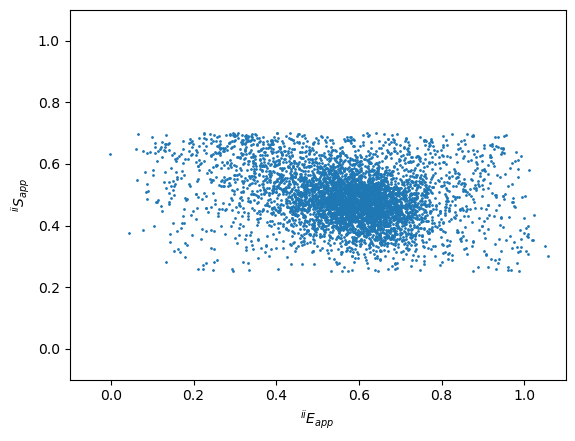

In [2]:
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], s=1.0)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Next, it is a good idea to check burst variance analysis.
This provides a qualatative check for within burst dynamics.



(0.0, 0.4)

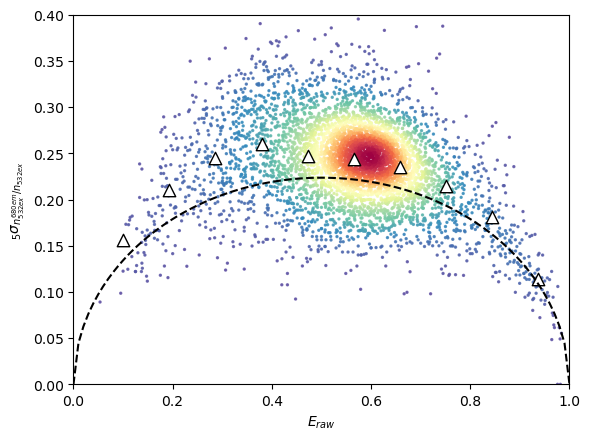

In [3]:
n = 5
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_bva*(1-x_bva))/n)

smf.plot.scatter(data, dbs['E_raw'], dbs['BVA5'], point_func=smf.plot.density_kde, s=2.0, alpha=0.8, cmap='Spectral_r')
smf.plot.scatter_meaninterval(data, dbs['E_raw'], dbs['BVA5'], marker='^', c='w', ec='k', s=80)
plt.plot(x_bva, y_bva, ls='--', c='k')
plt.xlim([0,1])
plt.ylim([0.0, 0.4])

Note the presence of a significant number of bursts above the static FRET line.

> **Note**
>
> In [Torella 2011](https://doi.org/10.1016/j.bpj.2011.01.066)
> recomended a more computationally expensive Monte-Carlo approach to compute a static FRET confidence interval.
> This is not implemented in smfbursts or H2MMbursts, but should be relatively straitforward to implement.
> Typcially however, as BVA is already a somewhat qualatative method, using the analytical expression above is sufficient.

### $\mathrm{H^{2}MM}$ optimization

#### Single Parameter Optimization

Typical H<sup>2</sup>MM anlaysis starts with optimizing a series of models of increasing numbers of states.
For this, the `bhm.StatePath.optimize_models()` method is used.

This method will optimize models, and return `StatePath` based `Param`s for each optimized model.

The first two arguments `origin` and `bursts` which define the source data and the burst selection, 
as `PhotonData`/`PhotonDataList` and `Param` respectively.

The next argument is `streams`, which defines which streams of photons are given to H<sup>2</sup>MM. 

For $\mathrm{\mu sALEX}$, all streams should have the same exciation period to avoid
detecting the alternation period. In the next subsection we will see a way to integrate
other periods.

This means our streams will be $n_{Dex}^{Dem}$, and $n_{Dex}^{Aem}$, ie

```python
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'))
```

> In the original H<sup>2</sup>MM paper
> [Prichi 2016](https://doi.org/10.1021/acs.jpcb.6b10726), it was demonstrated with only 2 color FRET, 
> and any alternating excitation streams were discarded, ie $n_{Dex}^{Dem}$ and $n_{Dex}^{Aem}$.
>  For $\mathrm{\mu sALEX}$, only streams in the same alternation period can be used.
> This is because if there is alternation, $H^{2}MM$ will detect the alternation rate
> over an real stochastic transistions.
> 
> In the next subsection, the method in
> [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x)
> (which also introduced the `H2MM_C` package on which `H2MMbursts` depends)
> It will be shown how the $n_{Aex}^{Aem} stream can be "shifted" into the
> donor excitation stream, enabling determination of stoichometry of states.

The `origin`, `bursts` and `streams` arguments define the input data to the H<sup>2</sup>MM algorithm.
The remaining arguments define optimization limits parameters.
These are

1. `conv_crit='pathBIC'` criterion to use to determine if optimizations have converged
2. `to_state=4` minimum number of states to optimize, regardless of convergence criterion
3. `min_states=1` which number of states to begin optimizing at
4. `max_states=8` maximum number of states to optimize, regardless of convergence criterion
5. additional kwargs are assumed to be inputs to
   [H2MM_C.h2mm_model.optimize()](https://h2mmpythonlib.readthedocs.io/en/latest/Documentation.html#H2MM_C.h2mm_model.optimize)
   Some useful parameters are:
    1. `max_iter` set the maximum number of iterations per optimization
    2. `converged_min` set the minimum difference in loglikelihood between rounds to consder model optimized
   
The name `StatePath` was chosen because most of the columns of this table are based on results from the *Viterbi* algorithm

The `StatePath` uses the *Viterbi* algorithm to determine the most like state of each photon
that was submitted H<sup>2</sup>MM processing (ie if the photon belongs to one of the photon streams in `streams`).

Conscutive photons in the same state define "dwells", which behave much in the same way like bursts.

The `Dwells` table is the `H2MMbursts` representation of these dwells, `Dwells` tables have all the same columns as `Bursts` tables.

By creating a `Dwells` param we can see how well the dwells match the predicted states.
Each dwell has a state, an this is represented in the column `state`, 
so in the code below a dictionary is created for storing H<sup>2</sup>MM `Param` and `Columns`,
which will include the state column.

Below is a typical example optimization:

In [4]:
streams_sp = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em')) # streams to submit to H2MM analysis
statepaths_sp = bhm.StatePath.optimize_models(data, dbs['bursts'], streams=streams_sp,
                                              conv_crit='BICph', thresh=0.005)
# generate default dwell params/columns
ddwell_sp = [bhm.fretfactory.make_dwell_dict(statepath) 
             for statepath in statepaths_sp]

The model converged after 2 iterations
The model converged after 288 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


The return value is a list of `Param` objects, based on the `StatePath` table class.

Because H<sup>2</sup>MM models typically need to be optimized first, it is rare to directly create a H<sup>2</sup>MM parameter.
Rather, we let `bhm.StatePath.optimize_models` create them from the optimized models.

Each `Param` in the list has 1 more state than the last.
Now the optimized models are examine to determine which one is the ideal model, neither over nor under fit.

After that, the ideal model can be interogated for its meaning regarding within burst dynamcs and states.

##### Comparing models

There are several different statistical discriminators used for comparing the "quality" of the model.
These are:
1. $BIC$ Bayes Information Criterion of model, the loglikelhood penalized for number of parameters and datapoints
2. $ICL$ Integrated Complete Likelihood, an output of the *Viterbi* algorithm assessing the forward probabiliy of the path
3. $BIC_{path}$ BIC of most likely state-path based on *Viterbi* algorithm

The order reflects how conservative these estimators are.
Generally it is best to take all information, both from statistical discriminators, and the models themselves,
into account before selecting the ideal model.

> **Note**
>
> The `conv_crit` selection `bhm.StatePath.optimize_models()` uses the selected discriminator to determine whether to stop or not.

We can plot the statistical discriminators for a sequence of `StatePath` `Param`s with the `bhm.plot.scatter_<discr>()` functions.

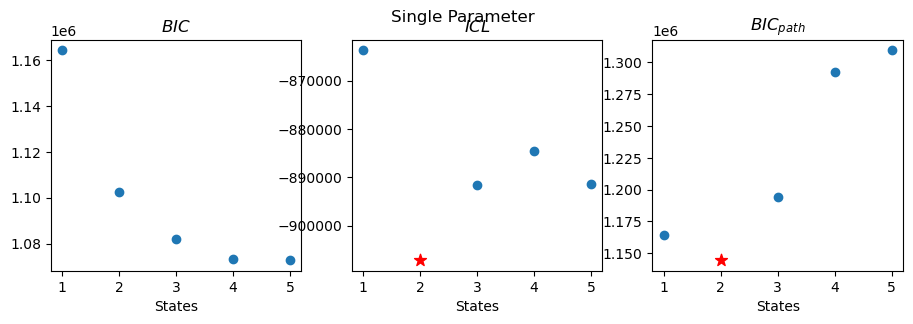

In [5]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BIC(data, statepaths_sp, ax=ax[0])
bhm.plot.scatter_ICL(data, statepaths_sp, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths_sp, ax=ax[2])
fig.suptitle('Single Parameter');

Another option is the `bhm.plot.scatter_<discr>ph()` functions, where the discriminator is divided by the number of photons in the data set.
Since the data is the same, this only rescales the values of the discriminators.
However, since the likelihood scales roughly with the number of photons, this division is a rough normalization for the values.

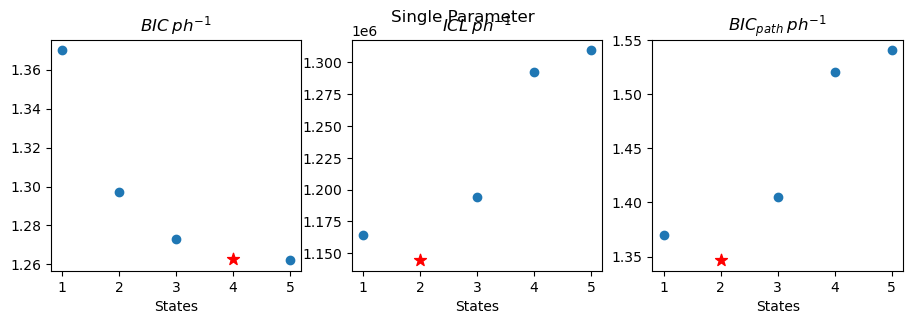

In [6]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths_sp, ax=ax[0], thresh=0.005)
bhm.plot.scatter_ICLph(data, statepaths_sp, ax=ax[1])
bhm.plot.scatter_pathBICph(data, statepaths_sp, ax=ax[2])
fig.suptitle('Single Parameter');

Here the $ICL$ and $BIC_{path}$ suggest a 2 state model, 
while $BIC$ has suggests 4 states, both models should be compared. 
With prior knowledge of the system,
we do not expect more than 2 FRET states, so it is more likely to be a 2 state model.

The $BIC$ typically "plateaus" so the ideal model is the start of the plataue, while $ICL$ and $BIC_{path}$ typically minimize at the ideal model.
When the plateau and minima are different, or perhaps the $ICL$ or $BIC_{path}$ plateau, 
the model selection requires examining each model and prior knowledge of the system to make the selection.

In the end, model selection is always a matter of the users judgement.

To examine the potentially best models, we plot the dwell distribution.
We also use the 
`bhm.plot.hist_model()` and `bhm.plot.hist_model_trans_arrows()`
to plot the locations of the states, and transition rates
on the histograms to compare the model based posistions
with their distributions derived from *Viterbi* dwells.


> **Note**
>
> The `bhm.plot.hist_model()` and `bhm.hist_model_trans_arrows()`
> works on any ratio based column, but will give an error for most other types of columns,
> later in the tutorial the method for getting a model value from a column will be explained in more detail.
>
> In this example we use columns already based on a $\mathrm{H^{2}MM}$ model,
> it is also possible to specify columsn as simple ratio based columsn of bursts,
> and *also* supply a `bhm.StatePath` based param (or other StatePath-like param)
> as a `statepath` keyword argument.

##### Comparing single parameter results

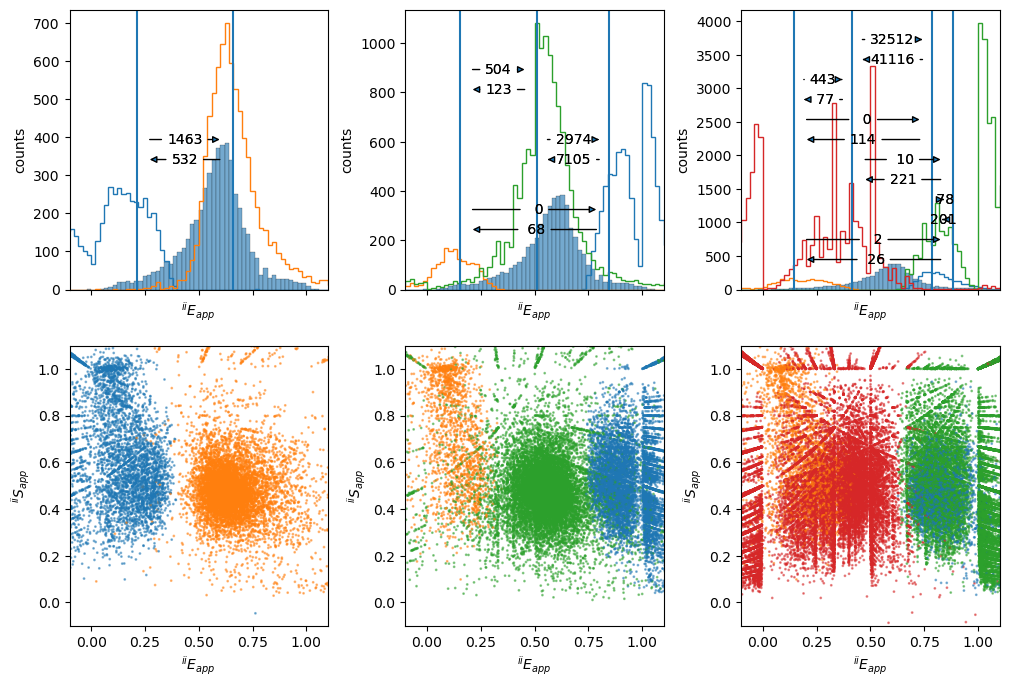

In [7]:
fig, ax = plt.subplots(2,3, figsize=(12,8), sharex=True, 
                       gridspec_kw={'wspace':0.3})
states = [2,3,4]

hbar_kws = smf.fretfactory.ALEXdefaults[('bins', 'ratio_bins'), 'histbar']


for i, state in enumerate(states):
    dwelldct = ddwell_sp[state-1]
    smf.plot.hist_bar(data, dbs['E_bg'], ax=ax[0,i],
                        **hbar_kws)
    bhm.plot.hist_model(dwelldct['E_bg'], data=data, ax=ax[0, i])
    bhm.plot.hist_model_trans_arrows(dwelldct['E_bg'], data=data, ax=ax[0,i])
    for j in range(state):
        g = smf.make_isin_gate(dwelldct['State'], j)
        smf.plot.hist_stair(data, dwelldct['E_bg'], ax=ax[0,i],
                          bins=hbar_kws['bins'], gate=g)
    smf.plot.scatter(data, dwelldct['E_bg'], dwelldct['S_bg'], 
                     ax=ax[1,i], point_func=smf.plot.colorcategory, 
                     point_cols=dwelldct['State'], point_kwargs={'cmap':'tab10'},
                     s=1.0, alpha=0.5)
    ax[1,i].set_xlim([-0.1, 1.1])
    ax[1,i].set_ylim([-0.1, 1.1])

The 3 state model looks best, so let's extract that dictionary 
to it's own variable so we can access it for the rest of the tutorial.
(note this is just a nice convention for readability, 
it has no effect on the behavior of smfbursts or H2MMbursts)

In [8]:
sdwell_sp = ddwell_sp[2]

## Multi-parameter work-around

In [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x),
a method was demonstrated where the acceptor excitation photons were
shifted into the alternation periods of the donor excitation period.

Note that this means that the raw data is somewhat manipulated.

Alternation rates similar to the alternation period should be viewed sceptically
i.e. if the alternation rate faster than ~10 times the alternation rate,
especially if it is close to an interger multiple,
the value should be viewed skeptically, and additional analysis should verify
if it is an artefact or not.

H2MMbursts implements the shift using the `bhm.usAlexStatpath` class.
It behaves almost identically to `bhm.StatePath`, but with the addition of the
*"shift"* parameter (given as keyword in `bhm.usAlexStatePath.optimize_models`)

### Shift styles

In the *"shift"* parameter, we input a sequence of strings, the same length as streams.
Here we specify how each stream should be shifted in time.

If a stream is already in the "correct" excitation period, it should be "base".

If a stream is to be shifted, there are a number of options.
There are 3 choices to be made in specifying the shift parametes.
1. Should excitation periods remain "**c**ontiguous",
   or should photons be shifted to the "**n**earest" possible destination period
2. What shifting method should be used
   Options are:
   - "even" recomended, even distribution so acceptor excitation
     photons carry only information about the exciation period
   - "shift" apply linear shift, computationally least expensive,
     but causes chance of artefacts from "overlaping" time information
   - "rand0x\<hexcode\>" Use random number generate (hexcode serves as seed)
     to give photons random times within appropriate period
3. Which excitation period should photons be shifted into?

The basic formula is `<c/n><shiftmethod>:<destination period>`

Since our base is excitation 0, we will specify "neven:0"
so shift photons evenly into the nearest exciatation period (the donor ie 0 exciation period).

#### Visualizing shifts

We can create some dummy `usAlexStatePath` based `Param`s and the
`bhm.plot.burst_index()` function to see how the different options look.

Comments in the cell below explain each piece of code.
Note how the `bhm.plot.burst_index()` function behave behaves analagously
to `smf.plot.burst_dets()`, but now plotting the $\mathrm{H^{2}MM}$ index
instead of the detector, and taking a `bhm.StatePath`-like `Param` instead
of bursts.

(18110.5, 18110.8)

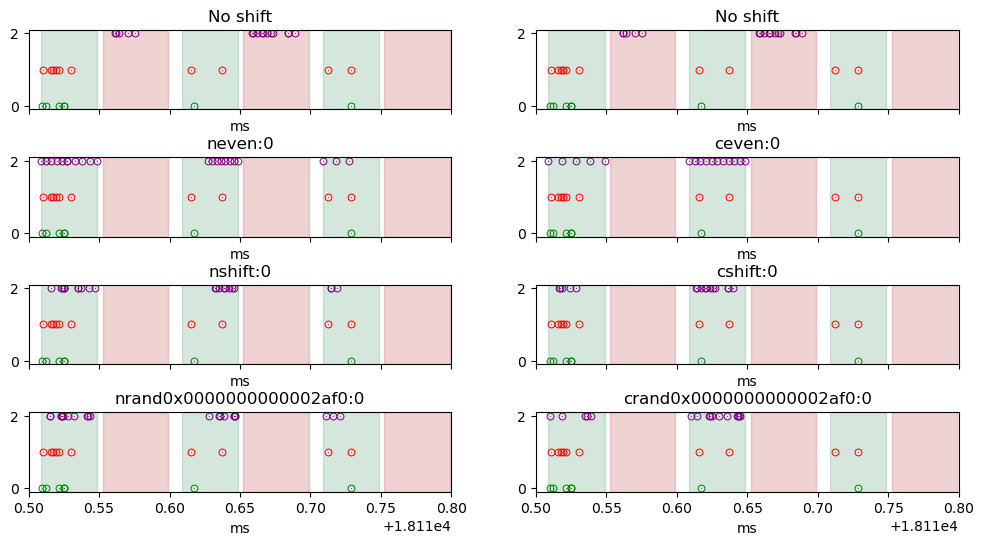

In [9]:
model = hm.factory_h2mm_model(2,3)
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))

# make "dumy" statepaths (these are not optimized, not useful for analysis)
# the unshifted model
sp_nones = [smf.Param(bhm.StatePath, 
                      params={'model':model, 'streams':streams},
                      parents={'bursts':dbs['bursts']})]*2
# example of even shift
evens = [('base', 'base', f'{cn}even:0') for cn in ['n', 'c']]
sp_evens = [smf.Param(bhm.usAlexStatePath, 
                      params={'model':model, 'streams':streams, 'shifts':even},
                      parents={'bursts':dbs['bursts']}) for even in evens]
# example of shift shift
shifts = [('base', 'base', f'{cn}shift:0') for cn in ['n', 'c']]
sp_shifts = [smf.Param(bhm.usAlexStatePath, 
                       params={'model':model, 
                               'streams':streams, 'shifts':shift},
                       parents={'bursts':dbs['bursts']}) for shift in shifts]
# example of rand shift
rands = [('base', 'base', f'{cn}rand0x2af0:0') for cn in ['n', 'c']]
sp_rands = [smf.Param(bhm.usAlexStatePath, 
                    params={'model':model, 'streams':streams, 'shifts':rnd},
                    parents={'bursts':dbs['bursts']}) for rnd in rands]

sp_list = [sp_nones, sp_evens, sp_shifts, sp_rands]

fig, ax = plt.subplots(4, 2, figsize=(12,6), 
                       gridspec_kw={'hspace':0.6}, sharex=True)
b = 10

index_pos = {0:0.0, 1: 1.0, 2:2.0}
index_kwargs = {0:{'c':'g'}, 1:{'c':'r'}, 2:{'c':'purple'}}

# build kwargs to set colors of excitation ranges
ex_clrs = ['seagreen', 'firebrick'] # colors of each excitation range
span_kwargs = [{'color':c} for c in ex_clrs] # list of dicts for each color
alt_span_kwargs = {'alpha':0.2, 'span_kwargs':span_kwargs} # input dict

# loop to build grid of plots
for i, sps in enumerate(sp_list):
    for j, sp in enumerate(sps):
        if sp is None:
            ax[i,j].set_axis_off()
            continue
        bhm.plot.burst_index(data.datas[0], sp, b, ax=ax[i,j], 
                             linewidths=5.0, s=0.5, zerostart=False, rescale=-3,
                             index_pos=index_pos, index_kwargs=index_kwargs,
                             alt_span=True, alt_span_kwargs=alt_span_kwargs)
        ttl = sp.params['shifts'][-1] if 'shifts' in sp.params else 'No shift'
        ax[i,j].set_title(ttl)
    
ax[0,0].set_xlim([18110.5, 18110.8])

In general the `neven:<ex>` option is recomended for the first optimization.
This is because
- the `n` option minimizes the time change introduced by the shift
- the `even` option removes potential artifacts
  from the distribution of photons in the other period (which should be ignored)

So below let's optimize with these options:

In [10]:
# streams to submit to H2MM analysis
streams_mp = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')) 
shifts = ('base', 'base', 'neven:0')
statepaths_mp = bhm.usAlexStatePath.optimize_models(data, dbs['bursts'], 
                                                    streams=streams_mp, 
                                                    shifts=shifts,
                                                    conv_crit='BICph', 
                                                    thresh=0.005)

ddwell_mp = [bhm.fretfactory.make_dwell_dict(statepath) 
             for statepath in statepaths_mp]

The model converged after 2 iterations
The model converged after 115 iterations
The model converged after 760 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


##### Comparing multiparameter results

We can use the $BIC$, $ICL$ and $BIC_{path}$ in teh same way as before

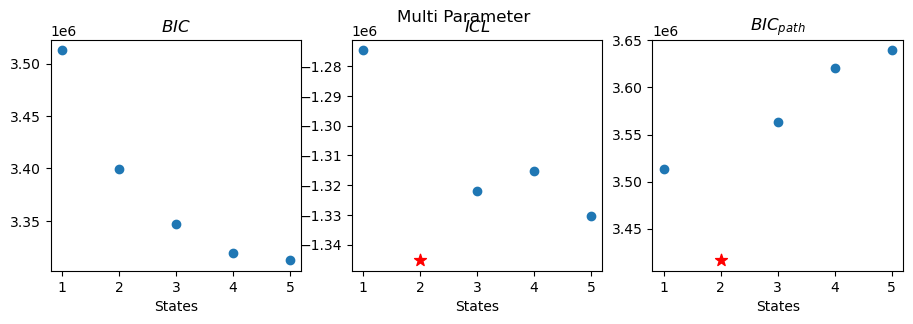

In [11]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BIC(data, statepaths_mp, ax=ax[0])
bhm.plot.scatter_ICL(data, statepaths_mp, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths_mp, ax=ax[2])
fig.suptitle('Multi Parameter');

And plot the per-photon as well, 
this allows us to better visualize the threshold for the BIC.

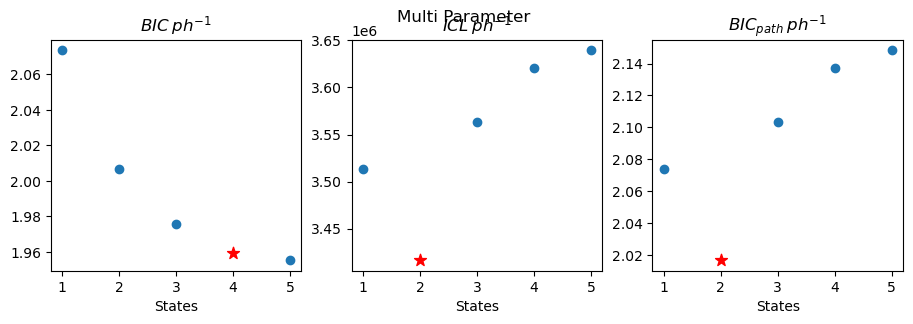

In [12]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths_mp, ax=ax[0], thresh=0.005)
bhm.plot.scatter_ICLph(data, statepaths_mp, ax=ax[1])
bhm.plot.scatter_pathBICph(data, statepaths_mp, ax=ax[2])
fig.suptitle('Multi Parameter');

Here, $BIC$ suggest 5 states, while the sharp dip in $ICL$ and $BIC_{path}$ suggest 3 states.
The 3, 4, and 5 state models should therefore be compared.

Note that this is an ideal example, and demonstrates "ideal" behavior.
The $BIC$ typically "plateaus" so the ideal model is the start of the plataue, while $ICL$ and $BIC_{path}$ typically minimize at the ideal model.
When the plateau and minima are different, or perhaps the $ICL$ or $BIC_{path}$ plateau, 
the model selection requires examining each model and prior knowledge of the system to make the selection.

In the end, model selection is always a matter of the users judgement.

Below we plot the dwell distribution, now that we have the acceptor excitation stream,
we can plot everything in the E-S plot.

The `bhm.plot.scatter_model` and `bhm.scatter_model_trans_arrows()` overlay the
model-predicted values and transitions with transition rates predicted by the model respectively.

This is very useful to overlay over the burst plot.

> **Note**
>
> The `bhm.plot.scatter_model` and `bhm.scatter_model_trans_arrows()`
> works on any ratio based column, but will give an error for most other types of columns,
> later in the tutorial the method for getting a model value from a column will be explained in more detail.

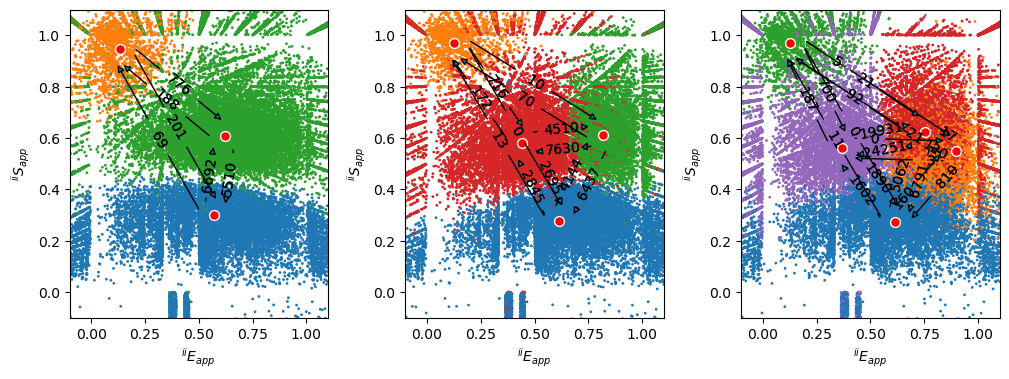

In [13]:
fig, ax = plt.subplots(1,3, figsize=(12,4),
                      gridspec_kw={'wspace':0.3})

states = [3,4,5]

for i, state in enumerate(states):
    dwelldct = ddwell_mp[state-1]
    smf.plot.scatter(data, dwelldct['E_bg'], dwelldct['S_bg'],
                     ax=ax[i], s=1.0,
                     point_func=smf.plot.colorcategory,
                     point_cols=dwelldct['State'],
                     point_kwargs={'cmap':'tab10'})
    bhm.plot.scatter_model(dwelldct['E_raw'], dwelldct['S_raw'],
                           data=data, ax=ax[i], s=50, c='r', ec='w')
    bhm.plot.scatter_model_trans_arrows(dwelldct['E_raw'], dwelldct['S_raw'],
                                        data=data, ax=ax[i])
    ax[i].set_xlim([-0.1, 1.1])
    ax[i].set_ylim([-0.1, 1.1])

In [14]:
sdwell_mp = ddwell_mp[3]

This also helps to identify states (and give them human readable names)

A simple "trick" to remember the states is to plot some invisible points with the colors you know will be used in the plot
(ie with the same color map), and plot the legend:

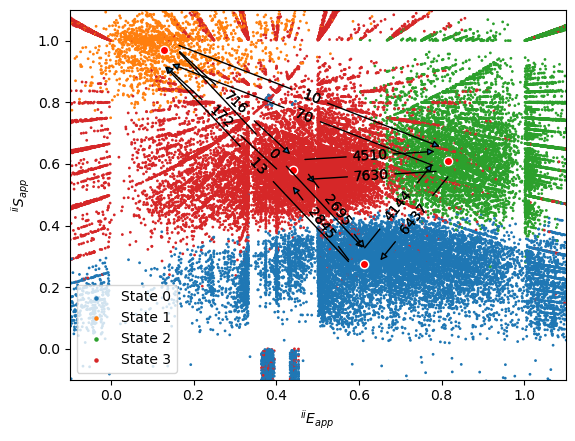

In [15]:
# plot dwell based parameters
smf.plot.scatter(data, sdwell_mp['E_bg'], sdwell_mp['S_bg'], 
                 point_func=smf.plot.colorcategory, 
                 point_cols=sdwell_mp['State'], 
                 s=1.0, point_kwargs={'cmap':mpl.colormaps['tab10']})

# overlay with state locations and transition rate arrows
bhm.plot.scatter_model(sdwell_mp['E_bg'], sdwell_mp['S_bg'],
                       data=data,
                       c='r', ec='w')
bhm.plot.scatter_model_trans_arrows(sdwell_mp['E_bg'], sdwell_mp['S_bg'], 
                                    data=data)

# invisible points to get color of states and plot in legend
for i in range(sdwell_mp['statepath'].params['model'].nstate):
    # 'tab10' colormap is the same as mpl.colormaps['tab10'] and 
    # calling with ([i]) returns color value of given number
    plt.scatter(np.nan, np.nan, s=5.0, 
                c=mpl.colormaps['tab10']([i]), label=f'State {i}')
plt.legend()


# ensure reasonable range is plotted (a few dwells often have extreme values)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1]);

The `StatePath` table (*not* `Dwells`) has a column similar to the state column.
This is "bstates", which identifies which states are present using a bit code.

This column can be used to present a burst-based plot where each burst is colored by the state(s) present within it.

To make naming states and setting colors easier, `burstH2MM` has the 
`bhm.plot.make_bstate_cmap()` and `bhm.plot.state_labels_bstate()` functions.

> **Note**
>
> For those who want to dig into the details within matplotlib and colormaps,
> see the matplotlib pages
> [Colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html),
> [Creating Colormaps](https://matplotlib.org/stable/users/explain/colors/colormap-manipulation.html),
> and in particular, the input to cmap should be a
> [ListedColorMap](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html)

The basic idea is
1. Give a name to each state, should be in order of states in model
2. Choose a color for each state, also in order of states in model
3. (optional) create an order array-
   the `order[i]`<sup>th</sup> element should be the index into `state` that should appear in the i<sup>th</sup> position
    - Note that the order in the H<sup>2</sup>MM model is always in reverse order of prevalence, so it is likely
      that the desired order will be reversed.

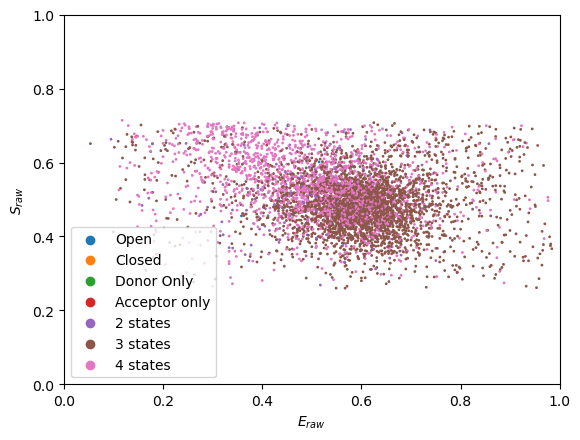

In [16]:
# inputs for make_bstate_cmap, name according to the dwell based plot, allows re-assiging colors etc.
state_names = ['Acceptor only', 'Donor Only', 'Closed', 'Open']
state_colors = mpl.colormaps['tab10'].colors
state_order = [3, 2, 1, 0]
# call make_bstate_cmap
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, state_colors, 
                                                order=state_order)

# plot burst-based plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], s=1, 
                 point_func=smf.plot.colorcategory, 
                 point_cols=smf.Column(sdwell_mp['statepath'], 'bstates'),
                 point_kwargs={'cmap':bcmap})
# helper function to add labels
bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order)
plt.legend()
plt.xlim([0,1.0])
plt.ylim([0,1.0]);

#### Retrieving model values

The model has 3 arrays:
1. prior - the probability of starting in a given state
2. trans - the probability of a transition between `[to state, from state]`
3. obs - the probability of emiting a photon in a given state, organized `[state, index]`

The optimized model is stored in the 'model' parameter of the `StatePath` `Param`:

In [17]:
sdwell_mp['statepath'].params['model']

nstate: 4, ndet: 3, nphot: 0, niter: 0, loglik: -inf converged state: 0x8000
prior:
0.025025708718474895, 0.06280149415437038, 0.08271385113261265, 0.8294589459945422
trans:
0.9999124791454664, 1.6400424810255448e-07, 5.1795842827305826e-05, 3.5561007458167026e-05
2.0821173719931792e-24, 0.9999909144828587, 1.30775159139208e-07, 8.95474198217399e-06
8.046345373832071e-05, 8.734660463279958e-07, 0.9998232897232728, 9.537335694257684e-05
3.368469677669492e-05, 2.1476361756415267e-06, 5.636958231140726e-05, 0.9999077980847363
obs:
0.10636942582332032, 0.16872591241737508, 0.7249046617593046
0.8460098890335589, 0.12328305887764304, 0.030707052088798203
0.11251766931574933, 0.49833529029063045, 0.38914704039362025
0.32447190965912304, 0.2549844133202813, 0.42054367702059564

The trans array has units of inverse macrotime clock.
The obs are the streams, so these can be interpreted similar intensities. 

`burstH2MM` provides a number of ways to transform these somewhat obtuse quantities into numbers that correspond to specific columns.

To convert transition rates into units of seconds, there is the `transrate` table property.

In [18]:
sdwell_mp['statepath'].transrate(data)

array([[7.99929983e+07, 1.31203398e+01, 4.14366743e+03, 2.84488060e+03],
       [1.66569390e-16, 7.99992732e+07, 1.04620127e+01, 7.16379359e+02],
       [6.43707630e+03, 6.98772837e+01, 7.99858632e+07, 7.62986856e+03],
       [2.69477574e+03, 1.71810894e+02, 4.50956658e+03, 7.99926238e+07]])

Since raw emission properties are rather hard to interpret, and states are typically defined by ratios, the `model_value` and `model_values`
parammethods implement conversion of model values to the expected equivalent.

In [19]:
sdwell_mp['statepath'].model_values(dbs['E_raw'], dbs['S_raw'])

(array([0.61333614, 0.12718865, 0.81580237, 0.44004078]),
 array([0.27509534, 0.96929295, 0.61085296, 0.57945632]))

Note that it is using `transrate` and `model_values` that the 
`bhm.plot.scatter_model()` and `bhm.plot.scatter_model_trans_arrows()` functions retrieve their values.

Not all columns can be assigned values.
All ratio-based columns can, however nph columns can't, 
since the number of photons in a burst is not only determined by emission probability, but also the variable duration of the burst.
Similarly, since H<sup>2</sup>MM has not information (in the clasic scheme) on nanotimes,
nanomean and nanohist columns also cannot be accessed with the `model_values` parammethod.

## Error Analysis

There are 2 main ways to assess error of an H<sup>2</sup>MM model.

1. loglikelihood
2. bootstrap

In the loglikelihood method, the model is adjusted until it the loglikelihood is reduced by some amount, typically 0.5.
This must be done per parameter, which always mean adjusting at least 2 values in a given array, since all model arrays are row stochastic (sum to 1).

In the bootstrap method, n optimizations are run on n subsets of the data, and the variance of each parameter is compared.
Because each subset allows all parameters to vary, the errors of all parameters can be computed simultameously.

For computing with the loglikelihood method, we use the `bhm.error.statepath_ll_error()` function.
It returns 2 values, the first is the lower bound, the second the upper bound.

So we can set `adjust='prior'` to find the error in the prior array

In [20]:
perrlow, perrhigh = bhm.error.statepath_ll_error(data, sdwell_mp['statepath'],
                                                 adjust='prior')
# merge prior arrays so [state, low/high]
np.array([[perrlow[i].prior[i], perrhigh[i].prior[i]] 
          for i in range(perrlow.shape[0])])

array([[0.03750329, 0.50000446],
       [0.06851276, 0.50000514],
       [0.064889  , 0.50000637],
       [0.49999554, 0.84448839]])

And with `adjust='trans'` we find the error in the trans arrays 
(divide by `data.clk_p` to get transition rates in units of $s^{-1}$)

In [21]:
terrlow, terrhigh = bhm.error.statepath_ll_error(data, sdwell_mp['statepath'], 
                                                 adjust='trans')
# merge trans arrays so [to-state, from-state, low/high]
np.array([[[terrlow[i,j].trans[i,j], terrhigh[i,j].trans[i,j]] 
           for j in range(terrlow.shape[1])] for i in range(terrlow.shape[0])])

array([[[9.99911806e-01, 9.99913147e-01],
        [1.17970924e-07, 2.12993423e-07],
        [5.11339080e-05, 5.24590506e-05],
        [3.50121709e-05, 3.61128208e-05]],

       [[4.81429364e-39, 6.22176050e-08],
        [9.99990694e-01, 9.99991132e-01],
        [9.36700904e-50, 3.05256508e-07],
        [8.73701064e-06, 9.17483513e-06]],

       [[7.93785182e-05, 8.15614551e-05],
        [7.79690413e-07, 9.69592223e-07],
        [9.99821718e-01, 9.99824828e-01],
        [9.41070062e-05, 9.66755075e-05]],

       [[3.31145571e-05, 3.42579516e-05],
        [2.08282038e-06, 2.21358919e-06],
        [5.55483056e-05, 5.72137431e-05],
        [9.99906909e-01, 9.99908668e-01]]])

And with `adjust='obs'` we find teh error in the bos array.

In [22]:
oerrlow, oerrhigh = bhm.error.statepath_ll_error(data, sdwell_mp['statepath'], 
                                                 adjust='obs')
# merge obs arrays so [state, index, low/high]
np.array([[[oerrlow[i,j].obs[i,j], oerrhigh[i,j].obs[i,j]] 
           for j in range(oerrlow.shape[1])] for i in range(oerrlow.shape[0])])

array([[[0.10574381, 0.10699501],
        [0.16796964, 0.16948364],
        [0.72399163, 0.72581866]],

       [[0.84430745, 0.84770568],
        [0.121834  , 0.12474053],
        [0.02976916, 0.03165853]],

       [[0.11170353, 0.1133348 ],
        [0.49719785, 0.499476  ],
        [0.38799865, 0.39029275]],

       [[0.32360095, 0.32534397],
        [0.2541733 , 0.25579807],
        [0.41959815, 0.42149171]]])

To compute the boostrap method, we use the `bhm.error.BootStrapError.evaluate()` classmethod to create a 
`bhm.error.BootStrapError` object that contains the optimized models, and from which the standard deviations and errors of each model array can be retrieved.

In [23]:
err = bhm.error.BootStrapError.evaluate(data, sdwell_mp['statepath'], n=10)

err.err_prior, err.err_trans, err.err_obs

Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
The model converged after 1706 iterations
The model converged after 1794 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


(array([0.00509667, 0.00640859, 0.01753347, 0.02467685]),
 array([[2.69357889e-05, 1.09480024e-05, 8.70038886e-06, 2.14884289e-05],
        [9.88831205e-06, 1.74868908e-05, 5.53477202e-06, 8.34020727e-06],
        [1.22433637e-05, 8.56149948e-06, 4.04024313e-05, 3.02027992e-05],
        [1.39594722e-05, 6.28863745e-06, 2.66546535e-05, 2.44402709e-05]]),
 array([[0.07154097, 0.04519551, 0.07301554],
        [0.11302996, 0.050775  , 0.09000872],
        [0.11546594, 0.0587931 , 0.0568035 ],
        [0.00577714, 0.00628458, 0.00523887]]))

## Simulations

The `bhm.sim.H2MMSim` param allows creating a Monte-Carlo simulation of the photon emissions based on a H<sup>2</sup>MM model.
The simulation mimics a `bhm.StatePath` so the params and parents are the same (with the addition of a random number generator seed).
This will work for the single parameter model, but since we use the subclass `bhm.
The photon emission times are fixed by the initial data, and thus will match those of the original data.
The Monte-Carlo simulation takes these times and first generates a statepath for those times,
and then assigns photon types based on said statepath.
It should be noted that photons are defined by the type of photon sorting.


There is a single parent:
- 'bursts' a `smf.Bursts` based Param, defining the bursts over which to simulate

The params are
- 'seed' an integer defining the randon number generator seed
- all parms of `bhm.StatePath` (defining the photon sorting)


Creating a `bhm.sim.H2MMSim` allows assessing the quallity of an H<sup>2</sup>MM model.
The results of `bhm.StatePath` and `bhm.sim.H2MMSim` (with the same model) should be comparable.

`bhm.sim.H2MMSim` functions like a `smf.photondata.BasePhotonTable`, 
and more specifically a subclass of `bhm.StatePath`.
However, the base is the 'bursts' parent
It "overwrites" the 'ph_...' columns, (except 'ph_times') and thus all columns derived from these recieve new values.

Below we create a simulation, generate the default columns, and plot the background corrected E and S histogram, 
sorting by burst state.

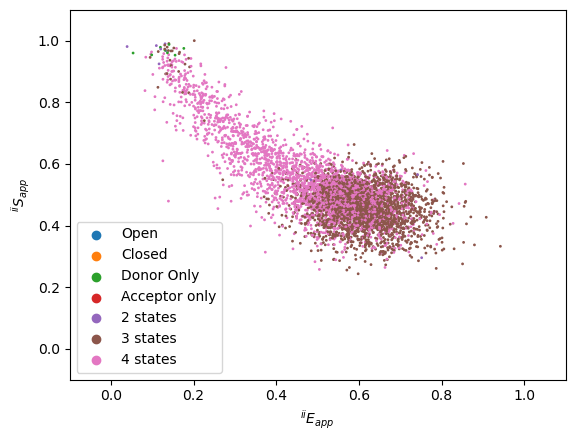

In [24]:
sim = smf.Param(bhm.sim.usAlexH2MMSim, 
                params={'model':sdwell_mp['statepath'].params['model'],
                        'streams':streams, 'shifts':shifts,
                        'seed':92},
                parents={'bursts':dbs['bursts']}) # add seed
dsim = smf.fretfactory.make_fret_from_base(sim)
dsim['Bstates'] = smf.Column(sim, 'bstates')

smf.plot.scatter(data, dsim['E_bg'], dsim['S_bg'], s=1.0, 
                 point_func=smf.plot.colorcategory, point_cols=dsim['Bstates'],
                 point_kwargs={'cmap':bcmap})
bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

Note that the difference between `bhm.usAlexStatePath` and `bhm.sim.usAlexH2MMSim` parameters
is the additon of the "seed" parameter.

So we can more easily re-create a simulation by taking the param-dict of the
`bhm.usAlexStatePath` param, and add in the seed, and use that in
creating our sim:

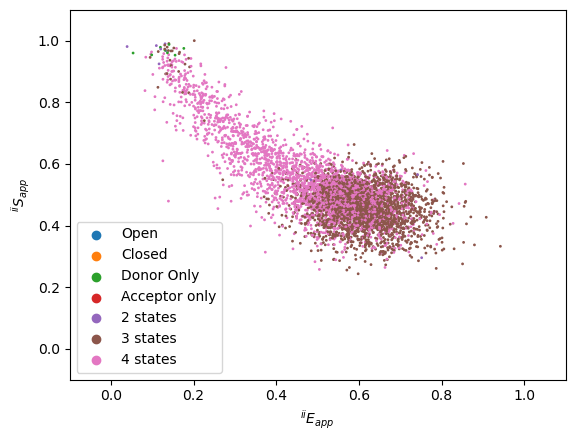

In [25]:
# generate params dictionary for simulation from existing 
sparam_dict = sdwell_mp['statepath'].params.asdict
sparam_dict['seed'] = 92

sim = smf.Param(bhm.sim.usAlexH2MMSim, 
                params={k:v for k, v in 
                        chain(sdwell_mp['statepath'].params.items(), # replicate parms of StatePath 
                              (('seed', 92), ))},
                parents={'bursts':dbs['bursts']}) # add seed
dsim = smf.fretfactory.make_fret_from_base(sim)
dsim['Bstates'] = smf.Column(sim, 'bstates')

smf.plot.scatter(data, dsim['E_bg'], dsim['S_bg'], s=1.0, 
                 point_func=smf.plot.colorcategory, point_cols=dsim['Bstates'],
                 point_kwargs={'cmap':bcmap})
bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

We can also generate a `bhm.Dwells` param from the `bhm.sim.H2MMSim`, since it is a sublcass of `bhm.modeltables.StatePathBase`,
which we can then plot the simulated well based E-S plot as well:

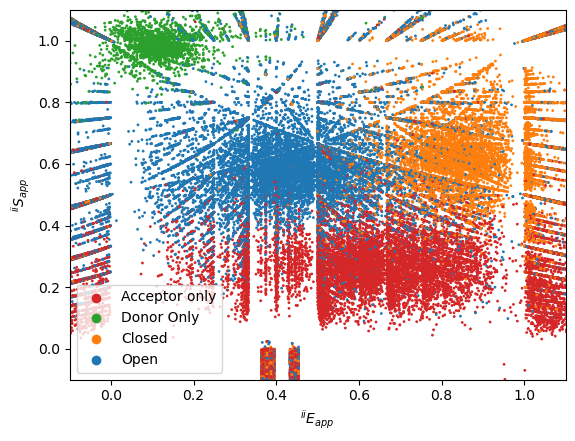

In [26]:
simdwell = smf.Param(bhm.sim.SimDwells, statepath=sim)
dsimdw = smf.fretfactory.make_fret_from_base(simdwell)
dsimdw['State'] = smf.Column(simdwell, 'state')

smf.plot.scatter(data, dsimdw['E_bg'], dsimdw['S_bg'], s=1.0, 
                 point_func=smf.plot.colorcategory, 
                 point_cols=dsimdw['State'], 
                 point_kwargs={'cmap':dcmap})
bhm.plot.state_labels_dwells(nlist, dcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

Now that we are done, don't forget to print the citations:

In [27]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Kapanidis, A. N. et al. Alternating-Laser Excitation of Single Molecules.
    Accounts of Chemical Research 38, 523–533 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A. N.
    Identifying molecular dynamics in single-molecule fret experiments with
    burst variance analysis. Biophysical J. 100, 1568–1577 (2011).
6. Pirchi, M. et al. Photon-by-Photon Hid

The cell below saves the statepath params into an HDF5 file, so that we can open them in other tutorials,
and therefore not have to re-run the optimizations to get the optimized models.

In [28]:
import tables as tb

with tb.open_file('data/statepathparams.hdf5', 'a') as f:
    dgroup = f.create_group(f.root, 'Yopo_Apo')
    modelsgroup = f.create_group(dgroup, 'statepath_params')
    for statepath in statepaths_mp:
        statepath.encode_group(modelsgroup, f'opt_{statepath.model.ndet}d_{statepath.model.nstate}s')

Thus concludes this tutorial.